In [1]:
from train_closed import make_env_fn
from evaluate import EvalInsulinPolicy, evaluate_insulin_policy
import argparse
import json
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor


patient="adult#005"
meals = "7:45,12:70,16:15,18:80,23:10"

meals = [
    (7 * 60, 45.0),
    (12 * 60, 70.0),
    (16 * 60, 15.0),
    (18 * 60, 80.0),
    (23 * 60, 10.0),
]

eval_env = DummyVecEnv([
    make_env_fn(
        env_id="simglucose-spid-eval-v0",
        patient=patient,
        meals=meals,
        max_episode_steps=480,
        seed=None,
        scenario_mode="fixed",
        time_std_multiplier=1,
        include_snacks=True,
        reward_type="smooth",
        warning_window_min=20,
        insulin_tau_min=55,
        sample_time_min=3,
        max_insulin_action=5,
        amount_noise_std_fraction=0,
        actual_time_noise_clip_min=0,
        actual_time_noise_std_min=0,
        use_bb_warmup=False,
        shield_bg_threshold=10
        
    )
])

eval_env = VecMonitor(eval_env)
model = PPO.load("./closed_benchmark/strict/adult-005/models/ppo_simglucose_200000_steps.zip", env=eval_env)

/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/gym/envs/registration.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import os
while not os.getcwd().endswith("GGSpeciale"):
    os.chdir("..")
os.chdir("code/SPID_code/")
from PySRWrapper import PySRPolicy

while not os.getcwd().endswith("GGSpeciale"):
    os.chdir("..")
os.chdir("simglucose_singlepatient/")
from evaluate import evaluate_insulin_policy
from train_closed import make_env_fn

os.getcwd()

/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


'/faststorage/project/GGSpeciale/GGSpeciale/simglucose_singlepatient'

In [3]:
import juliacall
from train_closed import make_env_fn
from evaluate import EvalInsulinPolicy, evaluate_insulin_policy
import argparse
import json
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor


patient="adult#005"
meals = "7:45,12:70,16:15,18:80,23:10"

meals = [
    (7 * 60, 45.0),
    (12 * 60, 70.0),
    (16 * 60, 15.0),
    (18 * 60, 80.0),
    (23 * 60, 10.0),
]

eval_env = DummyVecEnv([
    make_env_fn(
        env_id="simglucose-spid-eval-v0",
        patient=patient,
        meals=meals,
        max_episode_steps=480,
        seed=None,
        scenario_mode="fixed_hb",
        time_std_multiplier=1,
        include_snacks=True,
        reward_type="smooth",
        warning_window_min=20,
        insulin_tau_min=55,
        sample_time_min=3,
        max_insulin_action=5,
        amount_noise_std_fraction=0,
        actual_time_noise_clip_min=0,
        actual_time_noise_std_min=0,
        use_bb_warmup=False,
        shield_bg_threshold=10
        
    )
])



model = PySRPolicy.load(path="./distil_closed_benchmark/positive/adult-001/best_student_policy.joblib")

HISTORY CLEARED
Evaluating insulin policy...
Generating simglucose report...


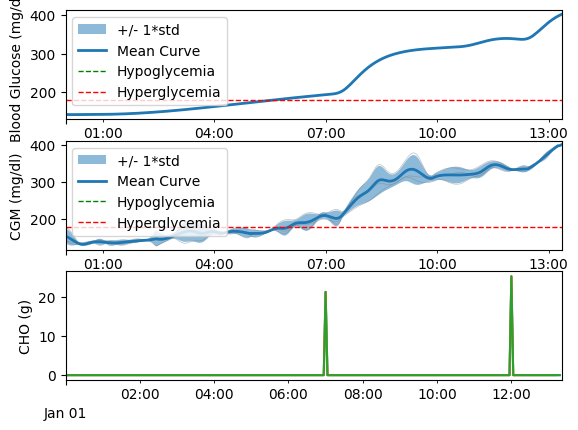

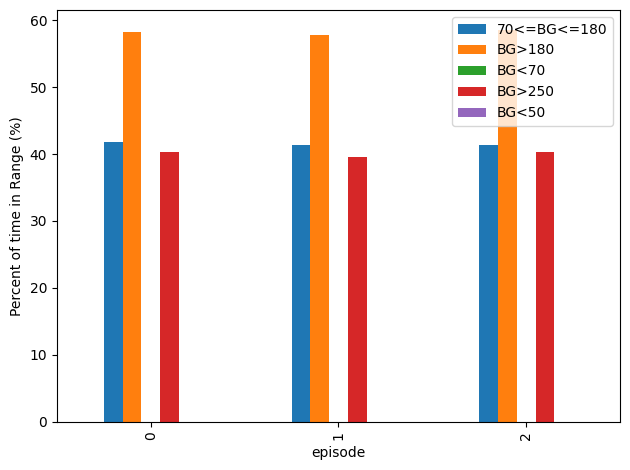

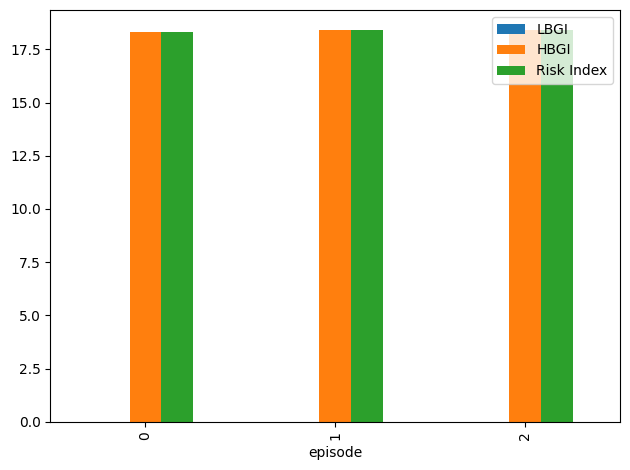

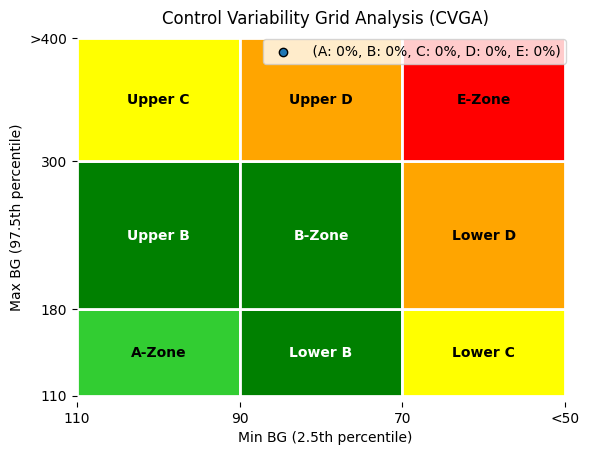

HISTORY CLEARED


{'metrics': {'eval_index': 0,
  'TBR_II': 0.0,
  'TBR_I': 0.0,
  'TIR': 41.80225281602002,
  'TAR_I': 58.19774718397998,
  'TAR_II': 39.92490613266583,
  'total_daily_insulin': 0.44610833333333333,
  'average_insulin': 0.0016749999999999996,
  'critical_failure_rate': 100.0,
  'num_timesteps': None,
  'mean_reward': -2657.7604308451214,
  'std_reward': 666.5625753777834,
  'n_eval_episodes': 3},
 'episode_rewards': [np.float64(-2387.469696074724),
  np.float64(-3574.996387206018),
  np.float64(-2010.8152092546225)],
 'episode_lengths': [np.int64(267), np.int64(265), np.int64(267)],
 'history':               eval_index                Time          BG         CGM  CHO  \
 episode step                                                                
 0       0              0 2018-01-01 00:00:00  141.221347  146.201977  0.0   
         1              0 2018-01-01 00:03:00  141.046354  140.240476  0.0   
         2              0 2018-01-01 00:06:00  140.905842  136.811555  0.0   
         3

In [4]:
#model = PPO.load("./closed_benchmark/strict/adult-005/models/ppo_simglucose_200000_steps.zip", env=eval_env)
%matplotlib inline
evaluate_insulin_policy(model, eval_env, save_path="./evaluation_test/test/",n_eval_episodes=3, deterministic=False,)

In [ ]:

evalCallback = EvalInsulinPolicy(eval_env, 
                                 eval_freq=1, 
                                 n_eval_episodes=20, 
                                 deterministic=False)

model.learn(
    total_timesteps=1,
    callback=[
        evalCallback,
    ],
    progress_bar=True
)

NameError: name 'EvalInsulinPolicy' is not defined